<a href="https://colab.research.google.com/github/cuongwork/test/blob/main/code_l%C6%B0u_tr%E1%BB%AF_b%E1%BA%A3n_cu%E1%BB%91i.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== ĐỌC VÀ KHÁM PHÁ DỮ LIỆU ===
Kích thước dữ liệu: (545, 13)

5 dòng đầu tiên:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Thống kê mô tả:
  

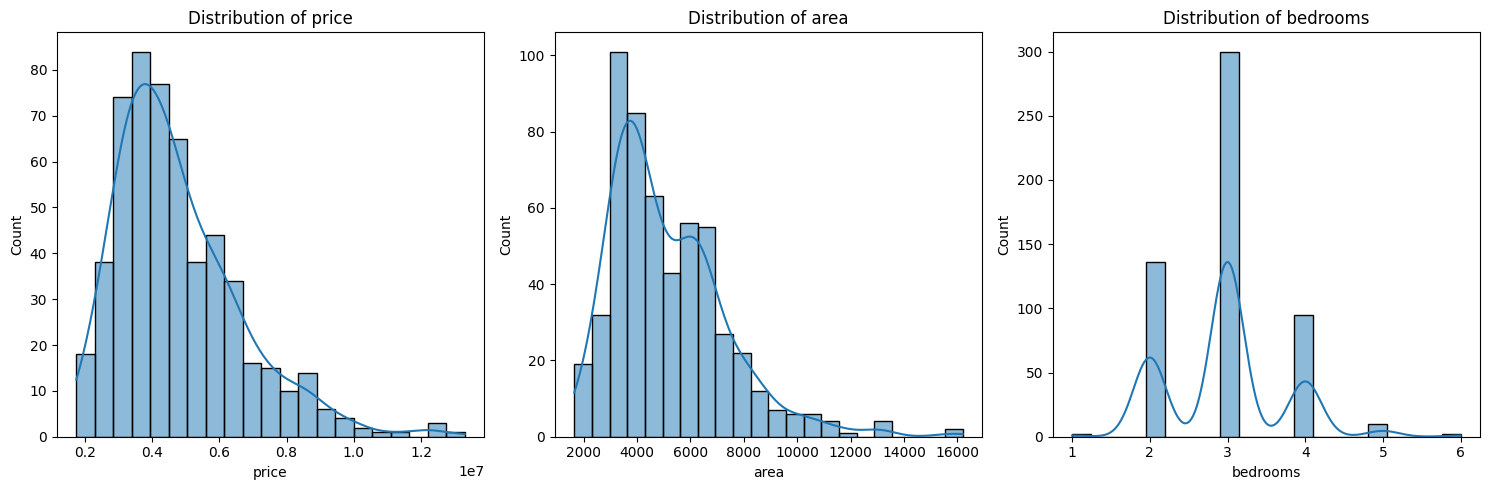

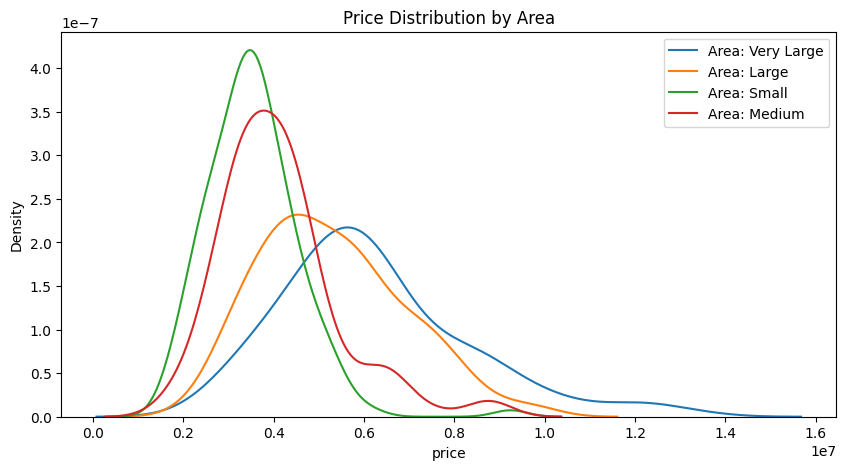

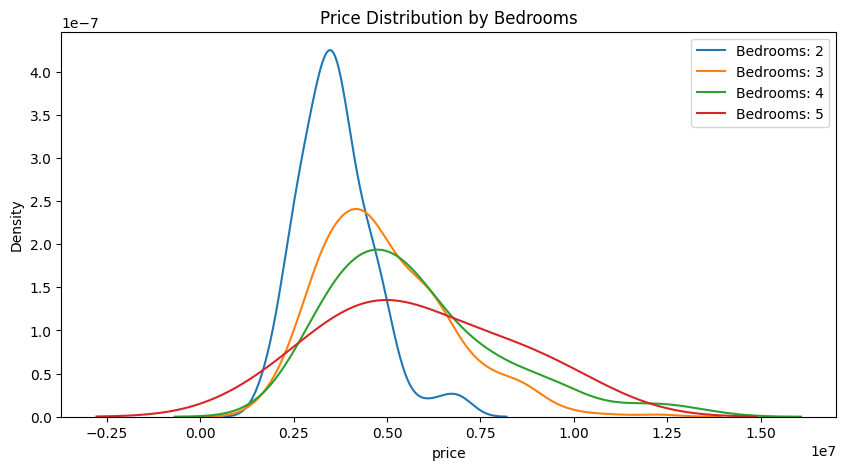


=== FEATURE ENGINEERING ===

=== ADDING LOG TRANSFORMATIONS ===

5 dòng đầu tiên sau khi thêm đặc trưng mới:
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  ...  area_category  \
0         0                0                1  ...     Very Large   
1         0                0                1  ...     Very Large   
2         1                0                0  ...     Very Large   
3         1                0                1  ...     Very Large   
4         1                0                1  ...     Very Large   

   area_per_bedroom  bath_per_room parking

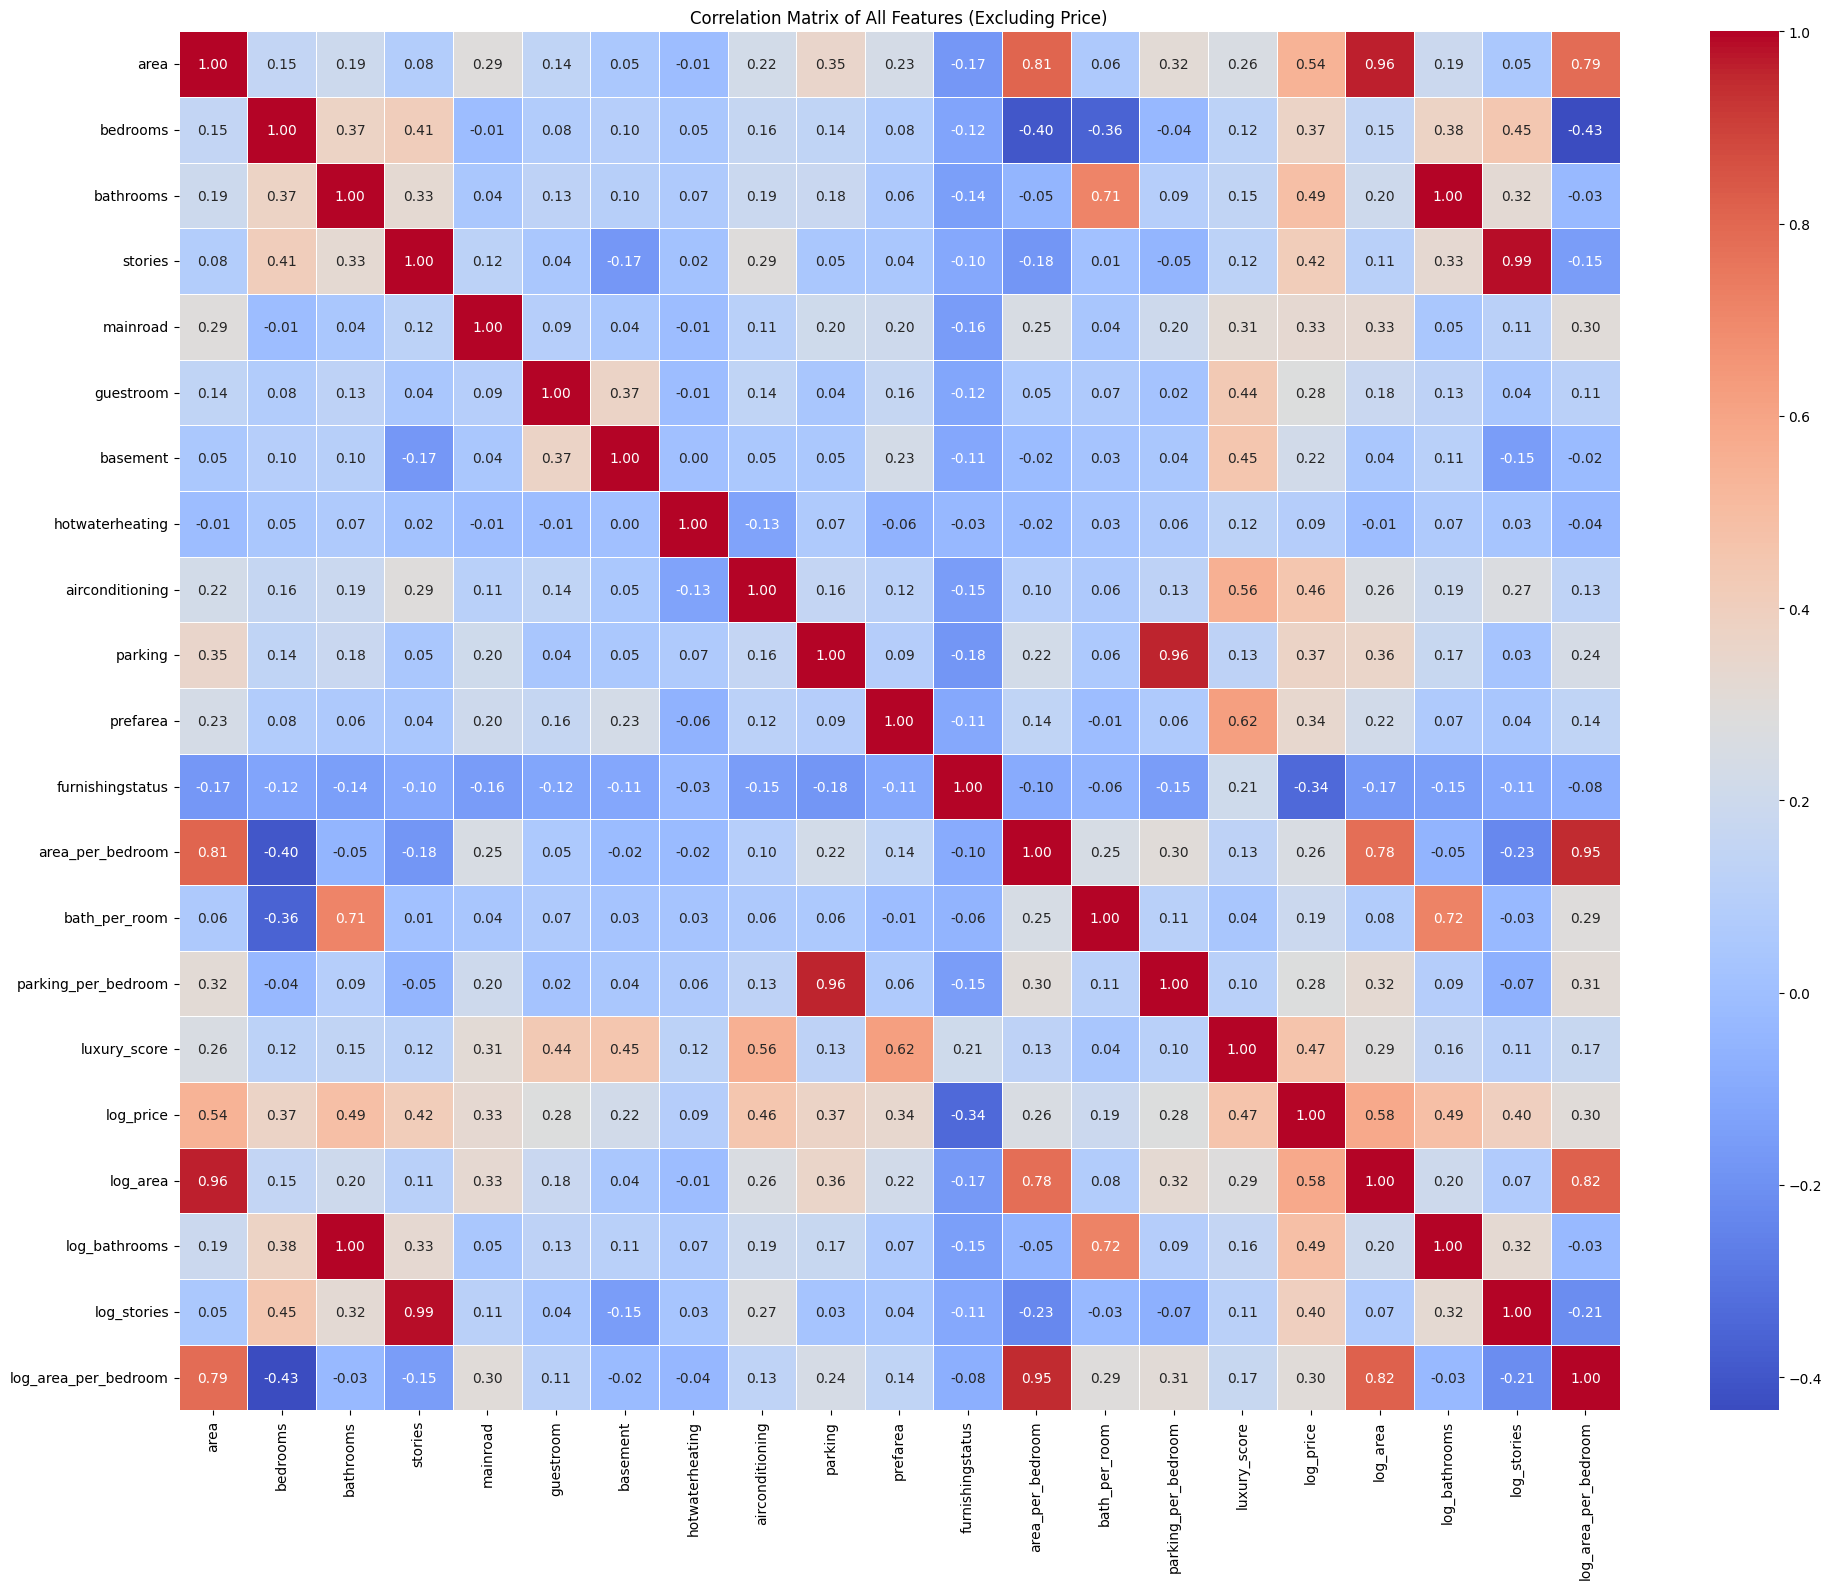


=== CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH ===
Kích thước tập huấn luyện: (381, 21)
Kích thước tập validation: (55, 21)
Kích thước tập kiểm thử: (109, 21)

=== XÂY DỰNG CÁC MÔ HÌNH VỚI CÁC PHƯƠNG PHÁP SCALING KHÁC NHAU ===

=== SO SÁNH CÁC MÔ HÌNH VỚI CÁC PHƯƠNG PHÁP SCALING KHÁC NHAU ===

Random Forest with Standard Scaling:
MAE: 18374.08
RMSE: 37357.60
R2: 0.9993

Random Forest with MinMax Scaling:
MAE: 18335.06
RMSE: 37217.78
R2: 0.9993

Random Forest with Log-transformed target and Standard Scaling:
MAE: 17880.99
RMSE: 36592.17
R2: 0.9994

Random Forest with Log-transformed target and MinMax Scaling:
MAE: 17851.90
RMSE: 36582.20
R2: 0.9994
Gradient Boosting với Standard Scaling:
MAE: 16129.49
RMSE: 27073.71
R2: 0.9997

Gradient Boosting với Log-transformed target:
MAE: 15210.46
RMSE: 25629.05
R2: 0.9997
XGBoost với Standard Scaling:
MAE: 53011.52
RMSE: 84661.65
R2: 0.9966

XGBoost với Log-transformed target:
MAE: 56139.46
RMSE: 86537.91
R2: 0.9965

=== SO SÁNH TẤT CẢ CÁC MÔ HÌNH ===


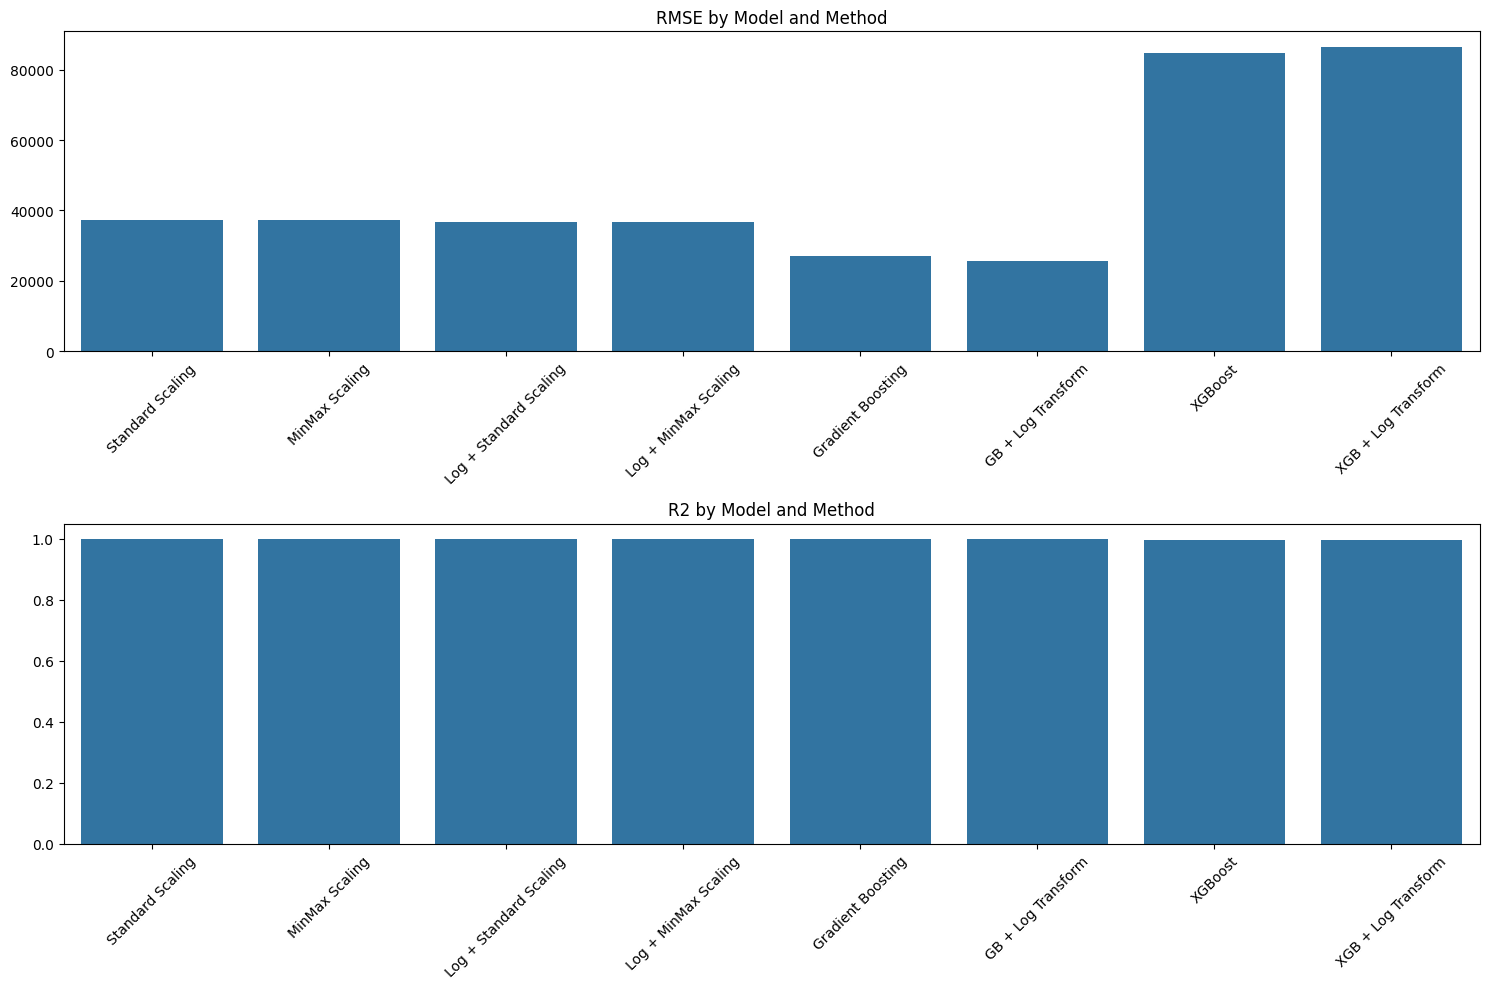


Bảng so sánh các mô hình:
                    Model           MAE          RMSE        R2
5      GB + Log Transform  15210.455646  25629.053858  0.999691
4       Gradient Boosting  16129.494600  27073.712453  0.999655
3    Log + MinMax Scaling  17851.897955  36582.204815  0.999370
2  Log + Standard Scaling  17880.988849  36592.174170  0.999370
1          MinMax Scaling  18335.061818  37217.776756  0.999348
0        Standard Scaling  18374.083636  37357.604971  0.999343
6                 XGBoost  53011.519531  84661.650161  0.996625
7     XGB + Log Transform  56139.464844  86537.913633  0.996474
Phương pháp tốt nhất là: GB + Log Transform

=== PHÂN TÍCH RESIDUALS VỚI MÔ HÌNH TỐT NHẤT ===


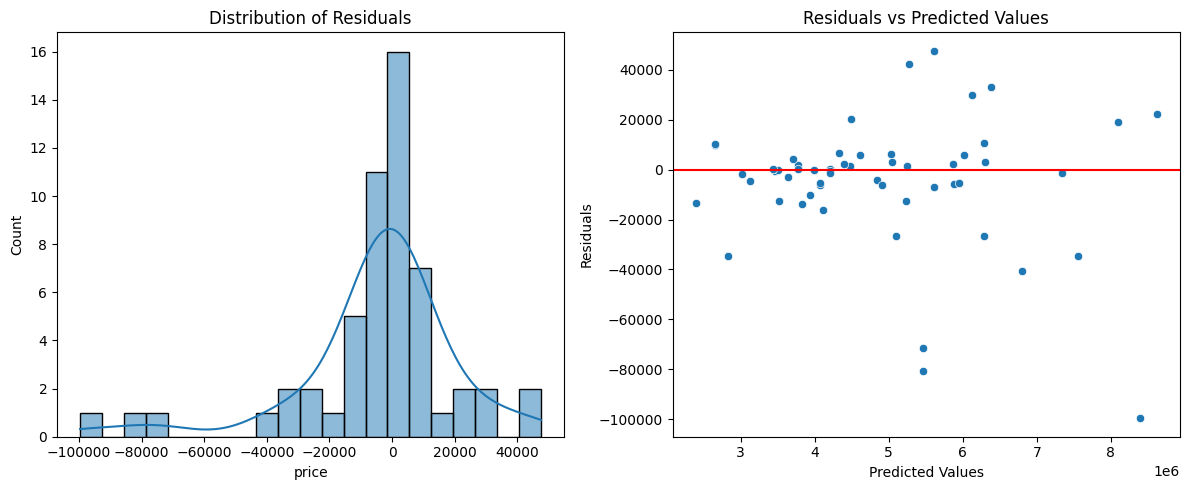


=== KẾT LUẬN ===
Mô hình tốt nhất là GB + Log Transform
R2 Score: 0.9997
RMSE: 25629.05
MAE: 15210.46

=== ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT TRÊN TẬP TEST ===

Kết quả đánh giá GB + Log Transform trên tập test:
MAE: 37728.84
RMSE: 175638.30
R2: 0.9939

So sánh kết quả giữa tập validation và tập test:
Validation MAE: 15210.46 | Test MAE: 37728.84
Validation RMSE: 25629.05 | Test RMSE: 175638.30
Validation R2: 0.9997 | Test R2: 0.9939

Chênh lệch giữa validation và test:
MAE diff: 22518.38 (148.05%)
RMSE diff: 150009.25 (585.31%)
R2 diff: 0.0058 (0.58%)


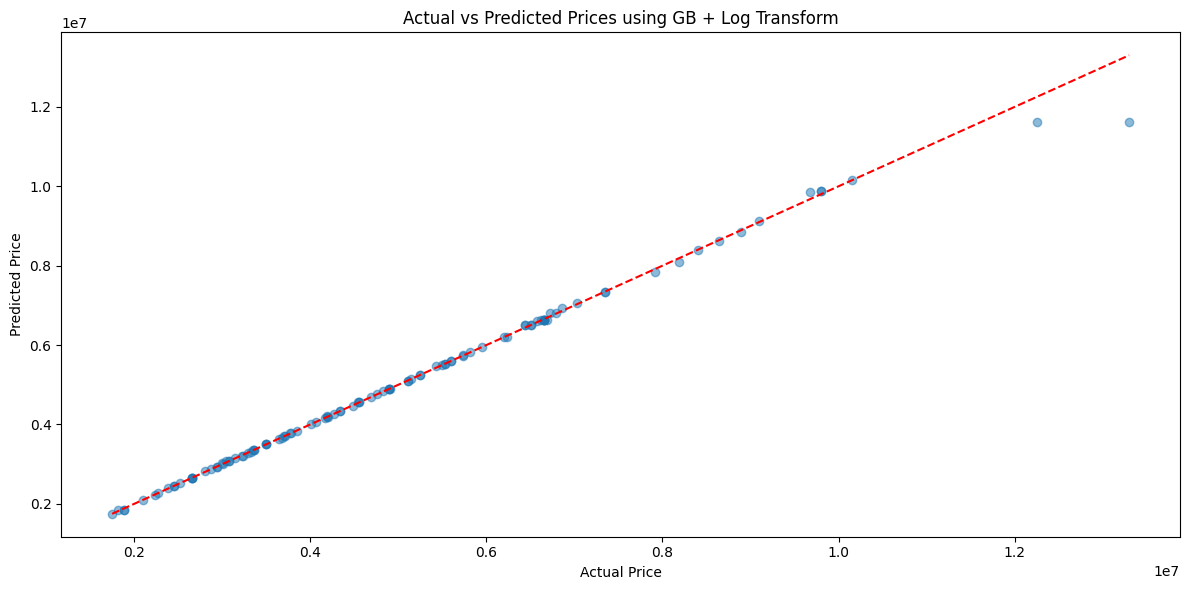

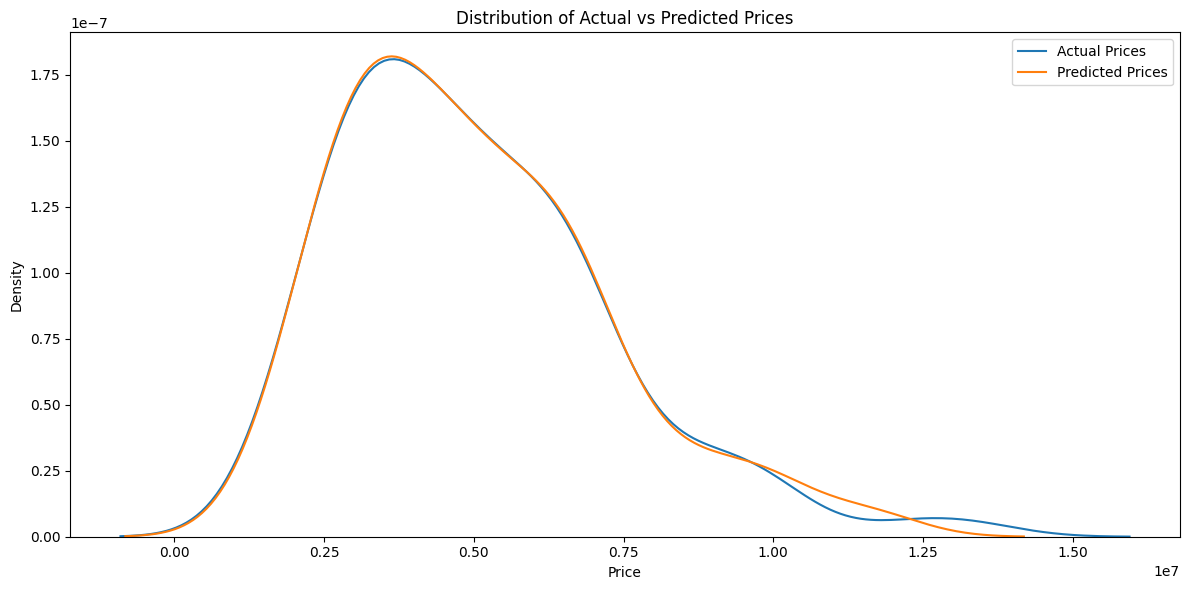


=== KẾT LUẬN CUỐI CÙNG ===
Mô hình tốt nhất là GB + Log Transform
Hiệu suất trên tập validation - R2: 0.9997, RMSE: 25629.05
Hiệu suất trên tập test - R2: 0.9939, RMSE: 175638.30

Mô hình có tính tổng quát tốt với hiệu suất tương đương giữa tập validation và test.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# 1. Đọc dữ liệu
print("=== ĐỌC VÀ KHÁM PHÁ DỮ LIỆU ===")
df = pd.read_csv("Housing.csv")
print(f"Kích thước dữ liệu: {df.shape}")

print("\n5 dòng đầu tiên:")
print(df.head())

print("\nThống kê mô tả:")
print(df.describe())

# 2. Tiền xử lý và phân tích dữ liệu
print("\n=== TIỀN XỬ LÝ VÀ PHÂN TÍCH DỮ LIỆU ===")

# Chuyển đổi các biến phân loại sang số bằng Label Encoding
categorical_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                       'airconditioning', 'prefarea', 'furnishingstatus']

# Áp dụng Label Encoder
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"\nLabel encoding for {col}:")
    for i, label in enumerate(le.classes_):
        print(f"  {label} -> {i}")

# Trực quan hóa phân phối các đặc trưng quan trọng
print("\n=== VISUALIZING KEY FEATURES ===")

# Tạo subplots cho các đặc trưng số (chỉ giữ lại phân phối của price, area và bedrooms)
numeric_features = ['price', 'area', 'bedrooms']

# Vẽ biểu đồ phân phối (distplot) cho các đặc trưng số còn lại
plt.figure(figsize=(15, 5))
for i, feature in enumerate(numeric_features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.savefig('numeric_features_distribution.png')
plt.show()

# Vẽ biểu đồ mật độ (density plot) cho giá theo area và bedrooms
# Price distribution by area - tạo categories từ area
df['area_category'] = pd.qcut(df['area'], 4, labels=['Small', 'Medium', 'Large', 'Very Large'])
plt.figure(figsize=(10, 5))
for category in df['area_category'].unique():
    sns.kdeplot(df[df['area_category'] == category]['price'], label=f'Area: {category}')
plt.title('Price Distribution by Area')
plt.legend()
plt.savefig('price_by_area.png')
plt.show()

# Price distribution by bedrooms
plt.figure(figsize=(10, 5))
for bedrooms in sorted(df['bedrooms'].unique()):
    if len(df[df['bedrooms'] == bedrooms]) > 5:  # Only plot if we have enough data points
        sns.kdeplot(df[df['bedrooms'] == bedrooms]['price'], label=f'Bedrooms: {bedrooms}')
plt.title('Price Distribution by Bedrooms')
plt.legend()
plt.savefig('price_by_bedrooms.png')
plt.show()

# 3. Feature Engineering: Tạo các đặc trưng mới
print("\n=== FEATURE ENGINEERING ===")
# 3.1 Tạo đặc trưng area_per_bedroom
df['area_per_bedroom'] = df['area'] / df['bedrooms']

# 3.2 Tạo đặc trưng bath_per_room
df['bath_per_room'] = df['bathrooms'] / (df['bedrooms'] + df['bathrooms'])

# 3.3 Tạo đặc trưng parking_per_bedroom
df['parking_per_bedroom'] = df['parking'] / df['bedrooms']
# Replace infinite values with 0
df.replace([np.inf, -np.inf], 0, inplace=True)

# 3.5 Tạo đặc trưng luxury_score
df['luxury_score'] = (
    (df['airconditioning'] * 1) +
    (df['hotwaterheating'] * 1) +
    (df['prefarea'] * 1) +
    (df['mainroad'] * 0.5) +
    (df['guestroom'] * 0.5) +
    (df['basement'] * 0.5)
)
# Add weight to furnishingstatus (0=unfurnished, 1=semi-furnished, 2=furnished)
df['luxury_score'] = df['luxury_score'] + (df['furnishingstatus'] * 0.5)

# Tạo thêm log transform cho các biến liên tục
print("\n=== ADDING LOG TRANSFORMATIONS ===")
continuous_features = ['price', 'area', 'bathrooms', 'stories', 'area_per_bedroom']

for feature in continuous_features:
    # Thêm 1 để tránh log(0)
    df[f'log_{feature}'] = np.log1p(df[feature])

# Hiển thị 5 dòng đầu tiên với các đặc trưng mới
print("\n5 dòng đầu tiên sau khi thêm đặc trưng mới:")
print(df.head())

# Vẽ biểu đồ tương quan giữa tất cả các đặc trưng số (ngoại trừ price)
print("\n=== CORRELATION MATRIX OF ALL FEATURES (EXCLUDING PRICE) ===")
# Loại bỏ area_category vì là đặc trưng dùng để trực quan hóa và loại bỏ price
numeric_df = df.drop(columns=['area_category', 'price'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(20, 16))  # Kích thước lớn hơn để hiển thị 22 đặc trưng (đã loại bỏ price)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of All Features (Excluding Price)')
plt.tight_layout()
plt.savefig('complete_correlation_matrix.png')
plt.show()

# 4. Chuẩn bị dữ liệu cho mô hình
print("\n=== CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH ===")

# Chia thành đặc trưng và nhãn
X = df.drop(columns=['price', 'area_category'])  # Đảm bảo loại bỏ area_category đã thêm
y = df['price']

# Thử nghiệm log transform cho biến mục tiêu
y_log = np.log1p(y)

# Chia dữ liệu thành 3 tập: training (70%), validation (10%), test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)  # 0.125 = 10/80

# Tương tự cho log-transformed target
_, _, y_log_temp, y_log_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
_, _, y_log_train, y_log_val = train_test_split(X_temp, y_log_temp, test_size=0.125, random_state=42)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập validation: {X_val.shape}")
print(f"Kích thước tập kiểm thử: {X_test.shape}")

# Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Chuẩn hóa dữ liệu bằng MinMaxScaler để so sánh
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_val_minmax = minmax_scaler.transform(X_val)
X_test_minmax = minmax_scaler.transform(X_test)

# Danh sách lưu tên các cột để tham chiếu sau này
feature_names = X.columns

# 5. Xây dựng các mô hình với các phương pháp scaling khác nhau
print("\n=== XÂY DỰNG CÁC MÔ HÌNH VỚI CÁC PHƯƠNG PHÁP SCALING KHÁC NHAU ===")

# 5.1 Xây dựng mô hình Random Forest với Standard Scaling
rf_model_std = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_std.fit(X_train_scaled, y_train)

# 5.2 Xây dựng mô hình Random Forest với MinMax Scaling
rf_model_minmax = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_minmax.fit(X_train_minmax, y_train)

# 5.3 Xây dựng mô hình Random Forest với Log-transformed target và Standard Scaling
rf_model_log_std = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_log_std.fit(X_train_scaled, y_log_train)

# 5.4 Xây dựng mô hình Random Forest với Log-transformed target và MinMax Scaling
rf_model_log_minmax = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_log_minmax.fit(X_train_minmax, y_log_train)

# 5.5 Xây dựng mô hình Gradient Boosting với Standard Scaling

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)


# 5.6 Xây dựng mô hình XGBoost

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
# 5.7 Xây dựng mô hình Gradient Boosting với Log-transformed target
gb_model_log = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model_log.fit(X_train_scaled, y_log_train)

# 5.8 Xây dựng mô hình XGBoost với Log-transformed target
xgb_model_log = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model_log.fit(X_train_scaled, y_log_train)


# 6. Đánh giá và so sánh các mô hình với các phương pháp scaling khác nhau
print("\n=== SO SÁNH CÁC MÔ HÌNH VỚI CÁC PHƯƠNG PHÁP SCALING KHÁC NHAU ===")

# 6.1 Đánh giá mô hình với Standard Scaling
y_pred_std = rf_model_std.predict(X_val_scaled)
mae_std = mean_absolute_error(y_val, y_pred_std)
mse_std = mean_squared_error(y_val, y_pred_std)
rmse_std = np.sqrt(mse_std)
r2_std = r2_score(y_val, y_pred_std)

print("\nRandom Forest with Standard Scaling:")
print(f"MAE: {mae_std:.2f}")
print(f"RMSE: {rmse_std:.2f}")
print(f"R2: {r2_std:.4f}")

# 6.2 Đánh giá mô hình với MinMax Scaling
y_pred_minmax = rf_model_minmax.predict(X_val_minmax)
mae_minmax = mean_absolute_error(y_val, y_pred_minmax)
mse_minmax = mean_squared_error(y_val, y_pred_minmax)
rmse_minmax = np.sqrt(mse_minmax)
r2_minmax = r2_score(y_val, y_pred_minmax)

print("\nRandom Forest with MinMax Scaling:")
print(f"MAE: {mae_minmax:.2f}")
print(f"RMSE: {rmse_minmax:.2f}")
print(f"R2: {r2_minmax:.4f}")

# 6.3 Đánh giá mô hình với Log-transformed target và Standard Scaling
y_pred_log_std = np.expm1(rf_model_log_std.predict(X_val_scaled))
mae_log_std = mean_absolute_error(y_val, y_pred_log_std)
mse_log_std = mean_squared_error(y_val, y_pred_log_std)
rmse_log_std = np.sqrt(mse_log_std)
r2_log_std = r2_score(y_val, y_pred_log_std)

print("\nRandom Forest with Log-transformed target and Standard Scaling:")
print(f"MAE: {mae_log_std:.2f}")
print(f"RMSE: {rmse_log_std:.2f}")
print(f"R2: {r2_log_std:.4f}")

# 6.4 Đánh giá mô hình với Log-transformed target và MinMax Scaling
y_pred_log_minmax = np.expm1(rf_model_log_minmax.predict(X_val_minmax))
mae_log_minmax = mean_absolute_error(y_val, y_pred_log_minmax)
mse_log_minmax = mean_squared_error(y_val, y_pred_log_minmax)
rmse_log_minmax = np.sqrt(mse_log_minmax)
r2_log_minmax = r2_score(y_val, y_pred_log_minmax)

print("\nRandom Forest with Log-transformed target and MinMax Scaling:")
print(f"MAE: {mae_log_minmax:.2f}")
print(f"RMSE: {rmse_log_minmax:.2f}")
print(f"R2: {r2_log_minmax:.4f}")

# 6.5 Đánh giá mô hình Gradient Boosting trên tập validation
y_pred_gb = gb_model.predict(X_val_scaled)
mae_gb = mean_absolute_error(y_val, y_pred_gb)
mse_gb = mean_squared_error(y_val, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_val, y_pred_gb)

print("Gradient Boosting với Standard Scaling:")
print(f"MAE: {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")
print(f"R2: {r2_gb:.4f}")

#6.6 Đánh giá mô hình Gradient Boosting với log-transformed target
gb_model_log = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model_log.fit(X_train_scaled, y_log_train)
y_pred_gb_log = np.expm1(gb_model_log.predict(X_val_scaled))
mae_gb_log = mean_absolute_error(y_val, y_pred_gb_log)
mse_gb_log = mean_squared_error(y_val, y_pred_gb_log)
rmse_gb_log = np.sqrt(mse_gb_log)
r2_gb_log = r2_score(y_val, y_pred_gb_log)

print("\nGradient Boosting với Log-transformed target:")
print(f"MAE: {mae_gb_log:.2f}")
print(f"RMSE: {rmse_gb_log:.2f}")
print(f"R2: {r2_gb_log:.4f}")

#6.7 Đánh giá mô hình XGBoost trên tập validation
y_pred_xgb = xgb_model.predict(X_val_scaled)
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
mse_xgb = mean_squared_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb)

print("XGBoost với Standard Scaling:")
print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R2: {r2_xgb:.4f}")

#6.8 Đánh giá với log-transformed target
xgb_model_log = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model_log.fit(X_train_scaled, y_log_train)
y_pred_xgb_log = np.expm1(xgb_model_log.predict(X_val_scaled))
mae_xgb_log = mean_absolute_error(y_val, y_pred_xgb_log)
mse_xgb_log = mean_squared_error(y_val, y_pred_xgb_log)
rmse_xgb_log = np.sqrt(mse_xgb_log)
r2_xgb_log = r2_score(y_val, y_pred_xgb_log)

print("\nXGBoost với Log-transformed target:")
print(f"MAE: {mae_xgb_log:.2f}")
print(f"RMSE: {rmse_xgb_log:.2f}")
print(f"R2: {r2_xgb_log:.4f}")



# 7. So sánh kết quả của tất cả các mô hình
results = {
    'Standard Scaling': {
        'MAE': mae_std,
        'RMSE': rmse_std,
        'R2': r2_std
    },
    'MinMax Scaling': {
        'MAE': mae_minmax,
        'RMSE': rmse_minmax,
        'R2': r2_minmax
    },
    'Log + Standard Scaling': {
        'MAE': mae_log_std,
        'RMSE': rmse_log_std,
        'R2': r2_log_std
    },
    'Log + MinMax Scaling': {
        'MAE': mae_log_minmax,
        'RMSE': rmse_log_minmax,
        'R2': r2_log_minmax
    },
    'Gradient Boosting': {
        'MAE': mae_gb,
        'RMSE': rmse_gb,
        'R2': r2_gb
    },
    'GB + Log Transform': {
        'MAE': mae_gb_log,
        'RMSE': rmse_gb_log,
        'R2': r2_gb_log
    },
    'XGBoost': {
        'MAE': mae_xgb,
        'RMSE': rmse_xgb,
        'R2': r2_xgb
    },
    'XGB + Log Transform': {
        'MAE': mae_xgb_log,
        'RMSE': rmse_xgb_log,
        'R2': r2_xgb_log
    },

}

# Trực quan hóa kết quả so sánh các phương pháp và mô hình
print("\n=== SO SÁNH TẤT CẢ CÁC MÔ HÌNH ===")

methods = list(results.keys())
maes = [results[method]['MAE'] for method in methods]
rmses = [results[method]['RMSE'] for method in methods]
r2s = [results[method]['R2'] for method in methods]

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
sns.barplot(x=methods, y=rmses)
plt.title('RMSE by Model and Method')
plt.xticks(rotation=45)
plt.tight_layout(pad=3.0)

plt.subplot(2, 1, 2)
sns.barplot(x=methods, y=r2s)
plt.title('R2 by Model and Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('all_models_comparison.png')
plt.show()

# Tạo bảng so sánh
print("\nBảng so sánh các mô hình:")
comparison_df = pd.DataFrame({
    'Model': methods,
    'MAE': maes,
    'RMSE': rmses,
    'R2': r2s
})
comparison_df = comparison_df.sort_values(by='R2', ascending=False)
print(comparison_df)



# Xác định mô hình tốt nhất dựa trên R2
best_method = max(results, key=lambda x: results[x]['R2'])
print(f"Phương pháp tốt nhất là: {best_method}")

# Chọn mô hình tương ứng để phân tích feature importance
if best_method == 'Standard Scaling':
    best_model = rf_model_std
elif best_method == 'MinMax Scaling':
    best_model = rf_model_minmax
elif best_method == 'Log + Standard Scaling':
    best_model = rf_model_log_std
elif best_method == 'Log + MinMax Scaling':
    best_model = rf_model_log_minmax
elif best_method == 'Gradient Boosting':
    best_model = gb_model
elif best_method == 'GB + Log Transform':
    best_model = gb_model_log
elif best_method == 'XGBoost':
    best_model = xgb_model
elif best_method == 'XGB + Log Transform':
    best_model = xgb_model_log

# Dự đoán trên tập validation với mô hình tốt nhất
if best_method in ['Standard Scaling', 'MinMax Scaling', 'Gradient Boosting', 'XGBoost', 'Neural Network']:
    if best_method == 'Standard Scaling':
        y_pred_best = rf_model_std.predict(X_val_scaled)
    elif best_method == 'MinMax Scaling':
        y_pred_best = rf_model_minmax.predict(X_val_minmax)
    elif best_method == 'Gradient Boosting':
        y_pred_best = gb_model.predict(X_val_scaled)
    elif best_method == 'XGBoost':
        y_pred_best = xgb_model.predict(X_val_scaled)

else:
    if best_method == 'Log + Standard Scaling':
        y_pred_best = np.expm1(rf_model_log_std.predict(X_val_scaled))
    elif best_method == 'Log + MinMax Scaling':
        y_pred_best = np.expm1(rf_model_log_minmax.predict(X_val_minmax))
    elif best_method == 'GB + Log Transform':
        y_pred_best = np.expm1(gb_model_log.predict(X_val_scaled))
    elif best_method == 'XGB + Log Transform':
        y_pred_best = np.expm1(xgb_model_log.predict(X_val_scaled))




# 9. Phân tích residuals với mô hình tốt nhất
print("\n=== PHÂN TÍCH RESIDUALS VỚI MÔ HÌNH TỐT NHẤT ===")

# Tính toán residuals
residuals = y_val - y_pred_best

# Vẽ biểu đồ phân phối residuals
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_best, y=residuals)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig('residuals_analysis.png')
plt.show()

print("\n=== KẾT LUẬN ===")
print(f"Mô hình tốt nhất là {best_method}")
print(f"R2 Score: {results[best_method]['R2']:.4f}")
print(f"RMSE: {results[best_method]['RMSE']:.2f}")
print(f"MAE: {results[best_method]['MAE']:.2f}")

# 10. Đánh giá mô hình tốt nhất trên tập test
print("\n=== ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT TRÊN TẬP TEST ===")

# Sử dụng mô hình tốt nhất đã xác định để dự đoán trên tập test
if best_method == 'Standard Scaling':
    y_test_pred = rf_model_std.predict(X_test_scaled)
    test_prefix = ""
elif best_method == 'MinMax Scaling':
    y_test_pred = rf_model_minmax.predict(X_test_minmax)
    test_prefix = ""
elif best_method == 'Log + Standard Scaling':
    y_test_pred = np.expm1(rf_model_log_std.predict(X_test_scaled))
    test_prefix = "log-transformed "
elif best_method == 'Log + MinMax Scaling':
    y_test_pred = np.expm1(rf_model_log_minmax.predict(X_test_minmax))
    test_prefix = "log-transformed "
elif best_method == 'Gradient Boosting':
    y_test_pred = gb_model.predict(X_test_scaled)
    test_prefix = ""
elif best_method == 'GB + Log Transform':
    y_test_pred = np.expm1(gb_model_log.predict(X_test_scaled))
    test_prefix = "log-transformed "
elif best_method == 'XGBoost':
    y_test_pred = xgb_model.predict(X_test_scaled)
    test_prefix = ""
elif best_method == 'XGB + Log Transform':
    y_test_pred = np.expm1(xgb_model_log.predict(X_test_scaled))
    test_prefix = "log-transformed "


# Tính toán các chỉ số đánh giá trên tập test
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nKết quả đánh giá {best_method} trên tập test:")
print(f"MAE: {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R2: {test_r2:.4f}")

# So sánh kết quả với tập validation
print("\nSo sánh kết quả giữa tập validation và tập test:")
print(f"Validation MAE: {results[best_method]['MAE']:.2f} | Test MAE: {test_mae:.2f}")
print(f"Validation RMSE: {results[best_method]['RMSE']:.2f} | Test RMSE: {test_rmse:.2f}")
print(f"Validation R2: {results[best_method]['R2']:.4f} | Test R2: {test_r2:.4f}")

# Kiểm tra sự chênh lệch giữa kết quả validation và test
mae_diff = abs(results[best_method]['MAE'] - test_mae)
rmse_diff = abs(results[best_method]['RMSE'] - test_rmse)
r2_diff = abs(results[best_method]['R2'] - test_r2)

print("\nChênh lệch giữa validation và test:")
print(f"MAE diff: {mae_diff:.2f} ({mae_diff/results[best_method]['MAE']*100:.2f}%)")
print(f"RMSE diff: {rmse_diff:.2f} ({rmse_diff/results[best_method]['RMSE']*100:.2f}%)")
print(f"R2 diff: {r2_diff:.4f} ({r2_diff/max(0.0001, results[best_method]['R2'])*100:.2f}%)")

# 11. Vẽ biểu đồ so sánh giá trị thực tế và dự đoán trên tập test
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted Prices using {best_method}')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

# 12. So sánh phân phối giá thực tế và dự đoán
plt.figure(figsize=(12, 6))
sns.kdeplot(y_test, label='Actual Prices')
sns.kdeplot(y_test_pred, label='Predicted Prices')
plt.xlabel('Price')
plt.title('Distribution of Actual vs Predicted Prices')
plt.legend()
plt.tight_layout()
plt.savefig('price_distributions.png')
plt.show()

# 13. Kết luận cuối cùng
print("\n=== KẾT LUẬN CUỐI CÙNG ===")
print(f"Mô hình tốt nhất là {best_method}")
print(f"Hiệu suất trên tập validation - R2: {results[best_method]['R2']:.4f}, RMSE: {results[best_method]['RMSE']:.2f}")
print(f"Hiệu suất trên tập test - R2: {test_r2:.4f}, RMSE: {test_rmse:.2f}")

if test_r2 < results[best_method]['R2'] - 0.05:
    print("\nCẢNH BÁO: Hiệu suất trên tập test thấp hơn đáng kể so với tập validation, có thể xảy ra overfitting.")
elif abs(test_r2 - results[best_method]['R2']) < 0.02:
    print("\nMô hình có tính tổng quát tốt với hiệu suất tương đương giữa tập validation và test.")
else:
    print("\nHiệu suất trên tập test khác với tập validation, có thể cần điều chỉnh mô hình.")


